In [29]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
np.random.seed(42) # Semente para reprodutibilidade

N_FIGURINHAS = 980 # Figurinhas no álbum
PRECO_FIGURINHA = 1 # R$ 1,00 por figurinha
N_SIMULACOES = 1_000 # Número de simulações

In [30]:
album = np.zeros(N_FIGURINHAS, dtype=bool) # Álbum vazio
album[:10]

array([False, False, False, False, False, False, False, False, False,
       False])

In [49]:
np.random.randint(0, N_FIGURINHAS) # Sorteia de maneira uniforme uma posição da figurinha no álbum

663

In [50]:
def simular_album():
    album = np.zeros(N_FIGURINHAS, dtype=bool) # Álbum vazio
    n_figurinhas = 0 # Figurinhas compradas
    while not album.all(): # Enquanto o álbum não estiver completo
        figurinha = np.random.randint(0, N_FIGURINHAS) # Sorteia uma figurinha
        album[figurinha] = True # Marca a figurinha como obtida
        n_figurinhas += 1 # Incrementa o contador de figurinhas compradas
    return n_figurinhas # Retorna o número de figurinhas compradas para completar o álbum

resultados = {
    'ID_SIMULACAO': [],
    'N_FIGURINHAS_COMPRADAS': [],
    'CUSTO_TOTAL': []
}
for i in range(N_SIMULACOES):
    print(f'Simulação {i+1}/{N_SIMULACOES}') # Mostra o progresso das simulações
    n_figurinhas = simular_album() # Simula a compra de figurinhas até completar o álbum
    resultados['ID_SIMULACAO'].append(i)
    resultados['N_FIGURINHAS_COMPRADAS'].append(n_figurinhas)
    resultados['CUSTO_TOTAL'].append(n_figurinhas * PRECO_FIGURINHA)
    
df = pd.DataFrame(resultados) # Cria um DataFrame com os resultados das simulações
df.head()

Simulação 1/1000
Simulação 2/1000
Simulação 3/1000
Simulação 4/1000
Simulação 5/1000
Simulação 6/1000
Simulação 7/1000
Simulação 8/1000
Simulação 9/1000
Simulação 10/1000
Simulação 11/1000
Simulação 12/1000
Simulação 13/1000
Simulação 14/1000
Simulação 15/1000
Simulação 16/1000
Simulação 17/1000
Simulação 18/1000
Simulação 19/1000
Simulação 20/1000
Simulação 21/1000
Simulação 22/1000
Simulação 23/1000
Simulação 24/1000
Simulação 25/1000
Simulação 26/1000
Simulação 27/1000
Simulação 28/1000
Simulação 29/1000
Simulação 30/1000
Simulação 31/1000
Simulação 32/1000
Simulação 33/1000
Simulação 34/1000
Simulação 35/1000
Simulação 36/1000
Simulação 37/1000
Simulação 38/1000
Simulação 39/1000
Simulação 40/1000
Simulação 41/1000
Simulação 42/1000
Simulação 43/1000
Simulação 44/1000
Simulação 45/1000
Simulação 46/1000
Simulação 47/1000
Simulação 48/1000
Simulação 49/1000
Simulação 50/1000
Simulação 51/1000
Simulação 52/1000
Simulação 53/1000
Simulação 54/1000
Simulação 55/1000
Simulação 56/1000
S

,ID_SIMULACAO,N_FIGURINHAS_COMPRADAS,CUSTO_TOTAL
0,0,6725,6725
1,1,5450,5450
2,2,5946,5946
3,3,7012,7012
4,4,8651,8651


In [51]:
df['CUSTO_TOTAL'].describe() # Estatísticas descritivas do custo total para completar o álbum

count     1000.000000
mean      7356.138000
std       1251.539135
min       4612.000000
25%       6479.000000
50%       7158.500000
75%       7988.750000
max      15116.000000
Name: CUSTO_TOTAL, dtype: float64

Custo médio: R$ 7356.14
Custo máximo: R$ 15116.00
Custo mínimo: R$ 4612.00
90º percentil do custo: R$ 8998.40


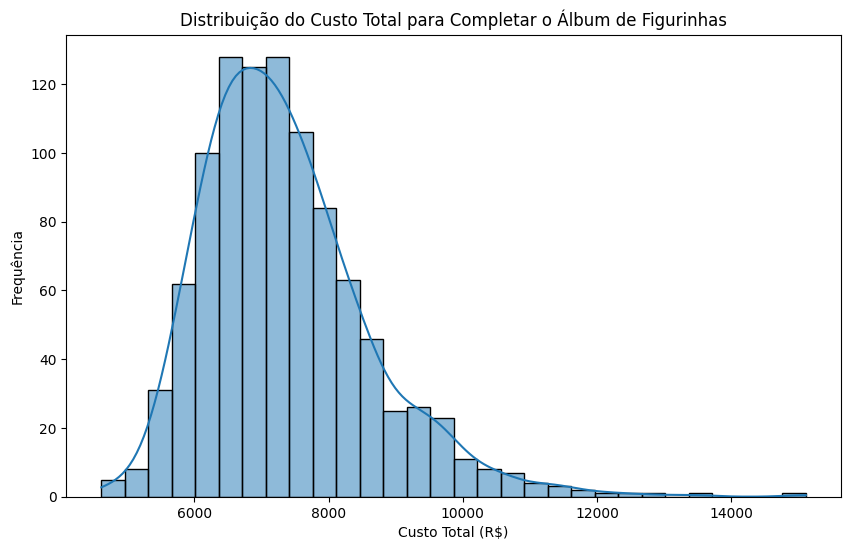

In [52]:
custo_medio = df['CUSTO_TOTAL'].mean() # Cálculo do custo médio
custo_maximo = df['CUSTO_TOTAL'].max() # Cálculo do custo máximo
custo_minimo = df['CUSTO_TOTAL'].min() # Cálculo do custo mínimo
custo_quartil_90 = df['CUSTO_TOTAL'].quantile(0.9) # Cálculo do 90º percentil do custo

print(f'Custo médio: R$ {custo_medio:.2f}')
print(f'Custo máximo: R$ {custo_maximo:.2f}')
print(f'Custo mínimo: R$ {custo_minimo:.2f}')
print(f'90º percentil do custo: R$ {custo_quartil_90:.2f}')

plt.figure(figsize=(10, 6))
sns.histplot(df['CUSTO_TOTAL'], bins=30, kde=True) # Histograma do custo total com curva de densidade
plt.title('Distribuição do Custo Total para Completar o Álbum de Figurinhas')
plt.xlabel('Custo Total (R$)')
plt.ylabel('Frequência')

plt.show();